In [8]:
!pip install -q kaggle
from google.colab import files
files.upload() # Pilih file kaggle.json yang baru saja diunduh

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafaelfrandhika","key":"e53bbf03c5cad06e697b68d617240154"}'}

In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API siap digunakan!")

✅ Kaggle API siap digunakan!


In [12]:
# Mencari dataset
!kaggle datasets list -s "ecommerce data"

# Download dataset (Ganti 'carrie1/ecommerce-data' sesuai dataset pilihan)
!kaggle datasets download -d carrie1/ecommerce-data

# Ekstrak file zip yang terunduh
!unzip ecommerce-data.zip


ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18311        212  0.7058824        
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9966         69  1                
mkechinov/ecommerce-behavior-data-from-multi-category-store     eCommerce behavior data from multi category store  4606720907  2019-12-09 20:43:39.273000          77219        857  1                
jocke

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='unicode_escape')
print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
(541909, 8)


In [21]:
# Cek info dan nilai kosong
print(df.info())
print("\nNilai kosong:")
print(df.isnull().sum())

# Bersihkan data
df = df.dropna()  # Hapus baris kosong
df = df[df['UnitPrice'] > 0]  # Hapus harga negatif/nol
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Ubah format tanggal
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']  # Buat kolom total penjualan

print("\n✅ Data bersih! Jumlah baris:", len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Nilai kosong:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

✅ Data bersih! Jumlah baris: 406789


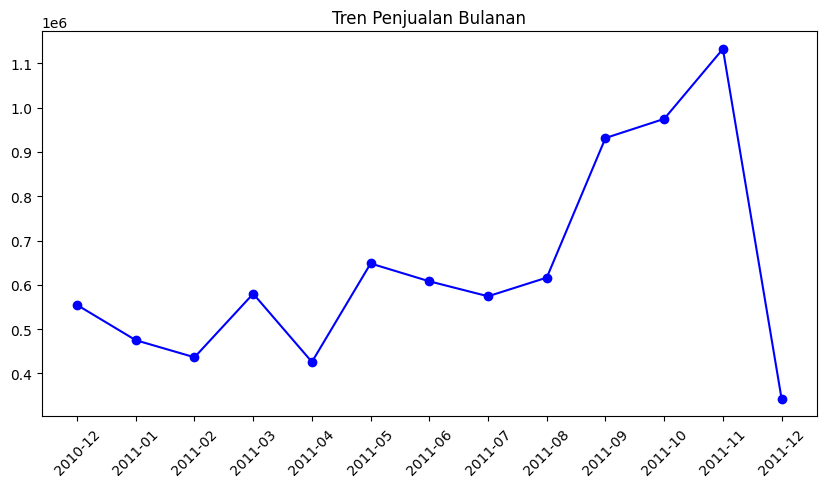

In [23]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

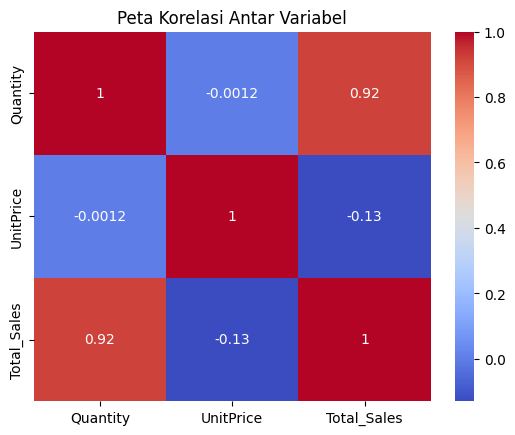

In [25]:
correlation = df[['Quantity', 'UnitPrice', 'Total_Sales']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

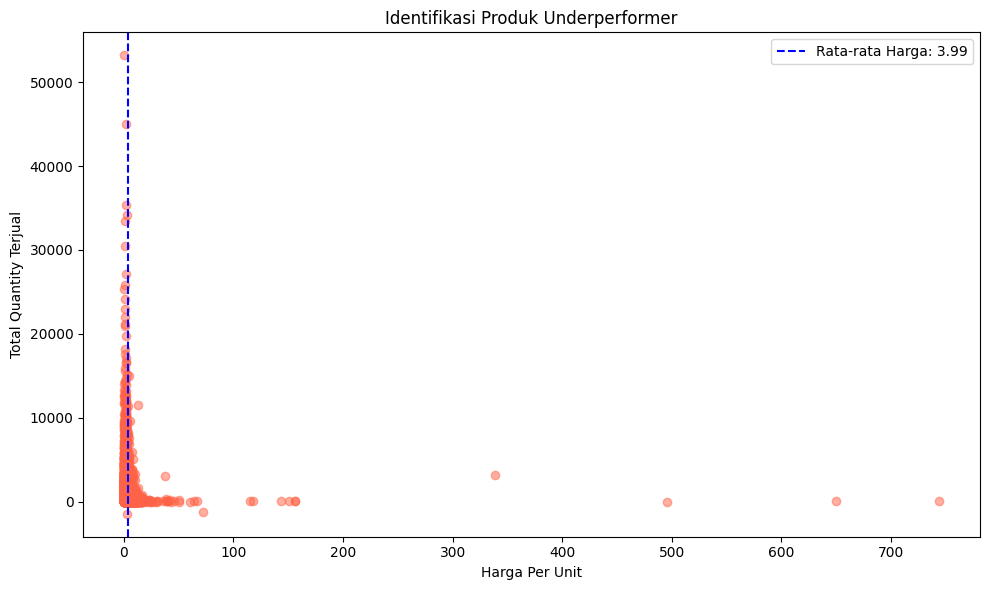

10 Produk Underperformer:
                         Description  Price_Per_Unit  Quantity
1066                        Discount       72.484545     -1194
882                  CRUK Commission      495.839375       -16
3702             WHITE CHERRY LIGHTS        6.750000        -8
456          BLUE PADDED SOFT MOBILE        4.250000        -6
3773     WOODEN BOX ADVENT CALENDAR         8.796154        -6
660     CHALKBOARD KITCHEN ORGANISER       23.750000        -4
2449              PINK CHERRY LIGHTS        6.750000        -4
188        ANTIQUE LILY FAIRY LIGHTS        4.950000        -3
870   CREAM SWEETHEART MAGAZINE RACK       15.950000        -3
872   CREAM SWEETHEART SHELF + HOOKS        7.950000        -1


In [26]:
product = df.groupby('Description').agg(
    Price_Per_Unit=('UnitPrice', 'mean'),
    Quantity=('Quantity', 'sum')
).reset_index()

avg_price = product['Price_Per_Unit'].mean()

plt.figure(figsize=(10, 6))
plt.scatter(product['Price_Per_Unit'], product['Quantity'], alpha=0.5, color='tomato')
plt.axvline(avg_price, color='blue', linestyle='--', label=f'Rata-rata Harga: {avg_price:.2f}')
plt.title('Identifikasi Produk Underperformer')
plt.xlabel('Harga Per Unit')
plt.ylabel('Total Quantity Terjual')
plt.legend()
plt.tight_layout()
plt.show()

# Tampilkan 10 produk underperformer terburuk
underperformer = product[product['Price_Per_Unit'] > avg_price].nsmallest(10, 'Quantity')
print("10 Produk Underperformer:")
print(underperformer)

In [27]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'count'),
    Monetary=('Total_Sales', 'sum')
).reset_index()

# Beri skor 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("✅ RFM Analysis selesai!")
print(rfm.head(10))

✅ RFM Analysis selesai!
   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Group
0     12346.0      326          2      0.00       1       1       1       111
1     12347.0        2        182   4310.00       5       5       5       555
2     12348.0       75         31   1797.24       2       3       4       234
3     12349.0       19         73   1757.55       4       4       4       444
4     12350.0      310         17    334.40       1       2       2       122
5     12352.0       36         95   1545.41       3       4       4       344
6     12353.0      204          4     89.00       1       1       1       111
7     12354.0      232         58   1079.40       1       3       4       134
8     12355.0      214         13    459.40       1       1       2       112
9     12356.0       23         59   2811.43       4       4       5       445


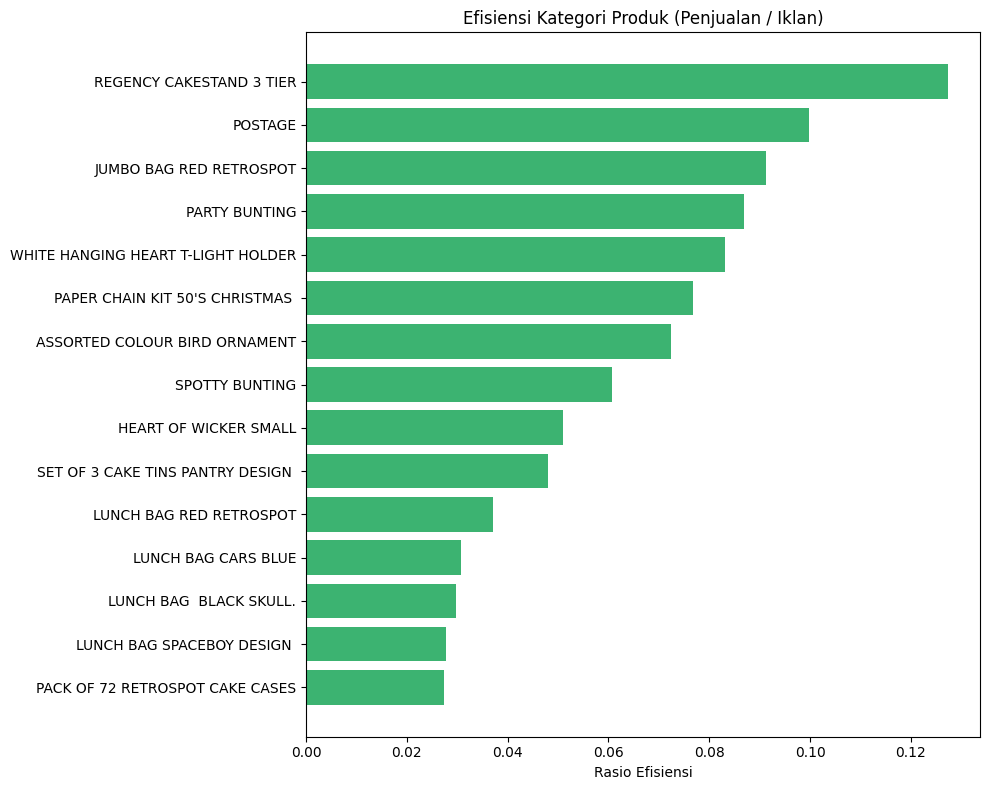

In [28]:
import numpy as np

# Dataset ini tidak punya Ad_Budget, kita simulasikan
np.random.seed(42)
df['Ad_Budget'] = np.random.uniform(100, 1000, size=len(df))

category_analysis = df.groupby('Description').agg(
    Total_Sales=('Total_Sales', 'sum'),
    Ad_Budget=('Ad_Budget', 'sum')
).reset_index()

category_analysis['Efisiensi'] = category_analysis['Total_Sales'] / category_analysis['Ad_Budget']
top_category = category_analysis.nlargest(15, 'Ad_Budget').sort_values('Efisiensi')

plt.figure(figsize=(10, 8))
plt.barh(top_category['Description'], top_category['Efisiensi'], color='mediumseagreen')
plt.title('Efisiensi Kategori Produk (Penjualan / Iklan)')
plt.xlabel('Rasio Efisiensi')
plt.tight_layout()
plt.show()

Rata-rata penjualan (Iklan Tinggi): Rp 20.08
Rata-rata penjualan (Iklan Rendah): Rp 20.73


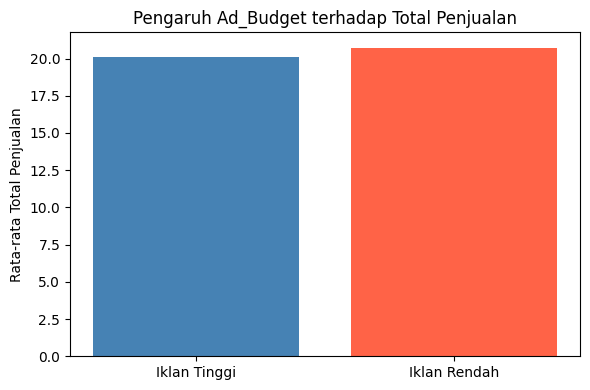

In [29]:
median_budget = df['Ad_Budget'].median()

iklan_tinggi = df[df['Ad_Budget'] > median_budget]['Total_Sales']
iklan_rendah = df[df['Ad_Budget'] <= median_budget]['Total_Sales']

print(f"Rata-rata penjualan (Iklan Tinggi): Rp {iklan_tinggi.mean():,.2f}")
print(f"Rata-rata penjualan (Iklan Rendah): Rp {iklan_rendah.mean():,.2f}")

plt.figure(figsize=(6, 4))
plt.bar(['Iklan Tinggi', 'Iklan Rendah'],
        [iklan_tinggi.mean(), iklan_rendah.mean()],
        color=['steelblue', 'tomato'])
plt.title('Pengaruh Ad_Budget terhadap Total Penjualan')
plt.ylabel('Rata-rata Total Penjualan')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Ad_Budget']]
y = df['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Koefisien Iklan : {model.coef_[0]:.4f}")
print(f"Akurasi Model (R² Score): {model.score(X_test, y_test):.4f}")

Koefisien Iklan : -0.0012
Akurasi Model (R² Score): -0.0000


In [36]:
import datetime as dt

# Dataset kita pakai 'InvoiceDate' bukan 'Order_Date'
# dan 'InvoiceNo' bukan 'Order_ID'
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                     # Frequency
    'Total_Sales': 'sum'                                      # Monetary
})

# Rename kolom agar mudah dibaca
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Memberikan skor 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Gabungkan skor menjadi satu segmen
rfm['RFM_Group'] = rfm.R_Score.astype(str) + rfm.F_Score.astype(str) + rfm.M_Score.astype(str)

print("✅ RFM Analysis selesai!")
print(rfm.head(10))

✅ RFM Analysis selesai!
            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                
12346.0         326          2      0.00       1       1       1       111
12347.0           2        182   4310.00       5       5       5       555
12348.0          75         31   1797.24       2       3       4       234
12349.0          19         73   1757.55       4       4       4       444
12350.0         310         17    334.40       1       2       2       122
12352.0          36         95   1545.41       3       4       4       344
12353.0         204          4     89.00       1       1       1       111
12354.0         232         58   1079.40       1       3       4       134
12355.0         214         13    459.40       1       1       2       112
12356.0          23         59   2811.43       4       4       5       445


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Ad_Budget']] # Fitur
y = df['Total_Sales'] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")


Koefisien Iklan: -0.0011603461595941255
Akurasi Model (R2 Score): -2.5255842822424768e-05
